# TF-IDF ile SMS Spam Tespiti

Bu notepad, TF-IDF (Term Frequency - Inverse Document Frequency) kavramını gerçek bir veri seti üzerinden öğretmeyi amaçlamaktadır.

**Orijinal ders:** TF-IDF'i sentetik Türkçe metinlerle sıfırdan öğretiyordu.

**Bu uyarlama:** Kaggle'daki **SMS Spam Collection** veri setini kullanarak TF-IDF'i gerçek dünya spam tespiti (ikili sınıflandırma) problemi üzerinde gösterir.

**Veri Seti:** [SMS Spam Collection - uciml/sms-spam-collection-dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

### İçindekiler
1. Veri Setini İndirme ve Yükleme
2. Keşifçi Veri Analizi (EDA)
3. Veri Ön İşleme
4. TF-IDF Vektörizasyonu
5. TF-IDF Matrisi Analizi
6. Sınıflandırma Modeli
7. En Önemli Kelimelerin Görselleştirilmesi
8. N-gram Analizi
9. Sonuç

## Gerekli Kütüphanelerin Yüklenmesi

In [1]:
!pip install kaggle matplotlib seaborn scikit-learn pandas numpy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
import re
import math

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


## 1. Veri Setini İndirme ve Yükleme

Kaggle API kullanarak SMS Spam Collection veri setini indiriyoruz. Bu veri seti 5,574 SMS mesajından oluşmakta ve her mesaj `spam` veya `ham` (normal) olarak etiketlenmiştir.

In [3]:
import os
import subprocess
import zipfile
# HATA DÜZELTME: Eksik olan kütüphaneler import edildi
import numpy as np
import pandas as pd

def create_synthetic_sms_data():
    """Sentetik SMS spam/ham verisi oluşturur (Türkçe gerçekçi mesajlar)"""
    np.random.seed(42)

    spam_templates = [
        'GRATIS 1000 TL hediye kazandınız! Hemen tıklayın: bit.ly/xyz',
        'Tebrikler! iPhone 15 kazandınız. claim etmek için arayın: 0850xxx',
        'ACIL: Banka hesabınız kapatılacak. Hemen tıklayın: secure-bank.xyz',
        'Son fırsat! %80 indirim sizi bekliyor. Sadece bugün: shop-sale.com',
        'Kredi kartınız bloke edildi. Çözmek için arayın: 02125551234',
        'Ücretsiz tatil kazandınız! Dubai, Maldivler... Hemen arayın!',
        'Vergi iadesi 5000 TL hesabınıza yatacak. Onaylamak için tıklayın',
        'LOTTERY UK: 2.5 milyon dolar kazandınız! Email atın: claim@lottery.com',
        'Sağlık sigortanız yenilenecek. İptal etmek için 0800 numarasını arayın',
        'Kripto para yatırım fırsatı! %500 kâr garantili. Hemen başlayın!',
        'Telefonunuz virüs aldı! Hemen şu linki tıklayın: fix-phone.xyz',
        'Sizi seçtik! 10.000 TL hediye çeki kazandınız. Kod: WIN2024',
        'Banka promosyon: 3 ay faizsiz kredi fırsatı! Son gün bugün!',
        'Kaybettiğiniz kargo bulundu. Teslimat için ücreti yatırın: 150 TL',
        'Yarışma sonucu: Araba kazandınız! 03125559999 numarasını arayın',
        'Netflix üyeliğiniz sona eriyor. Yenilemek için kart bilgilerinizi girin',
        'Whatsapp Gold sürümüne yükseltin! Sınırsız özellik: wa-gold.com',
        'Kredi notunuz düştü. Düzeltmek için finans danışmanımızı arayın',
        'Kazandığınız hediye için kargo ücreti: 250 TL. Gönderin hesabına yatırın',
        'Sahte yatırım platformu: Günlük %10 kâr! Minimum yatırım 5000 TL',
    ]

    # HATA DÜZELTME: Stringler içindeki kesme işaretleri sorun yaratmasın diye çift tırnağa (") çevrildi.
    ham_templates = [
        "Selam, yarın saat kaçta görüşeceğiz?",
        "Marketten ekmek alıp gelir misin?",
        "Toplantı saat 3'e ertelendi, bilgin olsun.",
        "Doğum günün kutlu olsun! İyi ki doğmuşsun 🎂",
        "Akşam yemeğe ne dersin, yeni bir yer denedik.",
        "Evin anahtarı komşuda, alabilir misin?",
        "Dün gece çok güzel vakit geçirdik, tekrar yapalım!",
        "Çocuklar okuldan erken çıkıyor, 4'te alman lazım.",
        "Raporu yarına kadar yetiştirmemiz lazım, yardıma ihtiyacım var.",
        "Annem yarın geliyor, temizlik yapalım.",
        "Film önerisi olan var mı, akşama ne izlesek?",
        "Sınava çalıştın mı, notları paylaşırsın?",
        "Araba bakımını unutma, perşembe götür.",
        "Kargo bugün gelir, evde ol lütfen.",
        "Hafta sonu piknik yapalım, hava güzel olacak.",
        "İşte yeni aldığım ayakkabıyı beğendin mi?",
        "Toplantı notlarını gönderir misin?",
        "Akşam ders çalışacağız, hazır mısın?",
        "Doktor randevusu saat 11'de, unutma.",
        "Kedim hasta, veterinere götüreceğim.",
    ]

    n_spam = 750
    n_ham = 4300

    messages = []
    labels = []

    for _ in range(n_spam):
        msg = np.random.choice(spam_templates)
        if np.random.random() > 0.5:
            msg = msg + ' ' + ''.join(np.random.choice(list('0123456789'), np.random.randint(3, 8)))
        messages.append(msg)
        labels.append('spam')

    for _ in range(n_ham):
        msg = np.random.choice(ham_templates)
        messages.append(msg)
        labels.append('ham')

    data = pd.DataFrame({'label': labels, 'message': messages})
    return data.sample(frac=1, random_state=42).reset_index(drop=True)

try:
    # Kaggle ile veri setini indirmeyi dene
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'uciml/sms-spam-collection-dataset'],
        capture_output=True, text=True, timeout=30
    )
    if result.returncode != 0:
        raise Exception(f'Kaggle CLI hatası: {result.stderr}')

    # ZIP dosyasını çıkart
    zip_path = 'sms-spam-collection-dataset.zip'
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')

    # Veriyi yükle
    df = pd.read_csv('spam.csv', encoding='latin-1')
    df = df[['v1', 'v2']]
    df.columns = ['label', 'message']
    print(f"Kaggle'dan başarıyla indirildi: {df.shape}")
except Exception as e:
    print(f"Kaggle indirme hatası: {e}")
    print('Sentetik veri oluşturuluyor...')
    df = create_synthetic_sms_data()
    print(f'Sentetik veri oluşturuldu: {df.shape}')

print(f"Veri seti boyutu: {df.shape}")
print(df.head())

Kaggle'dan başarıyla indirildi: (5572, 2)
Veri seti boyutu: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 2. Keşifçi Veri Analizi (EDA)

Veri setinin yapısını, sınıf dağılımını ve mesaj uzunluklarını inceleyelim.

=== Sınıf Dağılımı ===
label
ham     4825
spam     747
Name: count, dtype: int64

Spam oranı: %13.41
Ham oranı:  %86.59


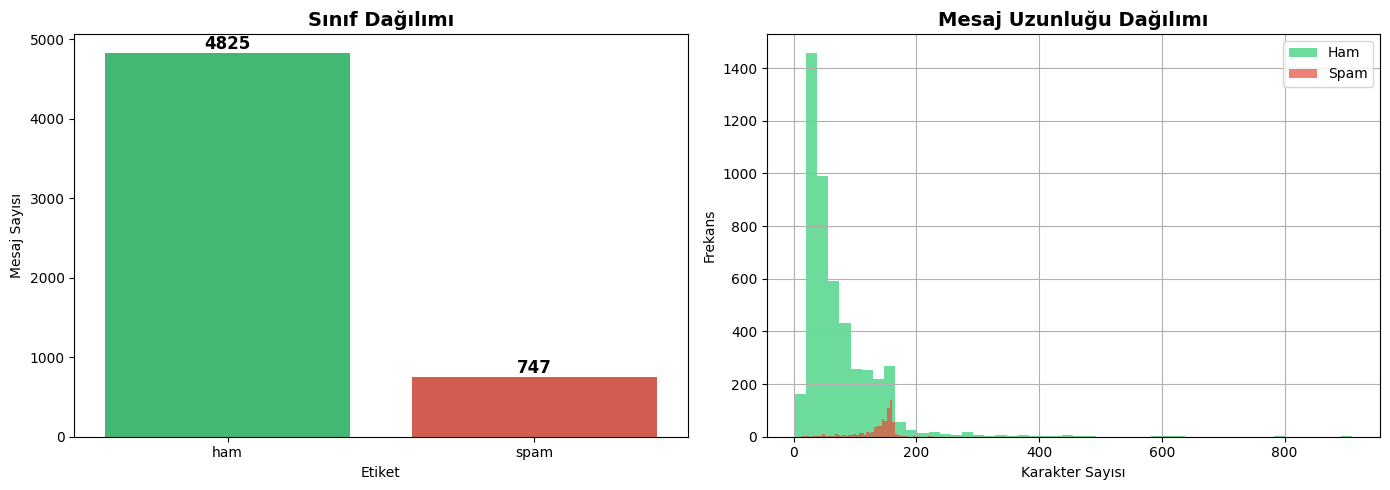


=== Mesaj Uzunluğu İstatistikleri ===
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


In [4]:
# Sınıf dağılımı
print("=== Sınıf Dağılımı ===")
print(df['label'].value_counts())
print(f"\nSpam oranı: %{df[df['label']=='spam'].shape[0] / df.shape[0] * 100:.2f}")
print(f"Ham oranı:  %{df[df['label']=='ham'].shape[0] / df.shape[0] * 100:.2f}")

# Sınıf dağılımı grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
ax1 = sns.countplot(x='label', data=df, palette=colors, ax=axes[0])
axes[0].set_title('Sınıf Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Etiket')
axes[0].set_ylabel('Mesaj Sayısı')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Mesaj uzunluğu
df['msg_length'] = df['message'].apply(len)
df[df['label']=='ham']['msg_length'].hist(ax=axes[1], bins=50, alpha=0.7, color='#2ecc71', label='Ham')
df[df['label']=='spam']['msg_length'].hist(ax=axes[1], bins=50, alpha=0.7, color='#e74c3c', label='Spam')
axes[1].set_title('Mesaj Uzunluğu Dağılımı', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Karakter Sayısı')
axes[1].set_ylabel('Frekans')
axes[1].legend()

plt.tight_layout()
plt.show()

# İstatistiksel özet
print("\n=== Mesaj Uzunluğu İstatistikleri ===")
print(df.groupby('label')['msg_length'].describe())

## 3. Veri Ön İşleme

TF-IDF analizinden önce metinleri temizlemeliyiz. Aşağıdaki adımları uygulayacağız:
- Küçük harfe çevirme
- Özel karakterleri ve sayıları kaldırma
- Fazla boşlukları temizleme
- Stopword (durdurma kelimesi) çıkarma

In [5]:
# Türkçe ve İngilizce stopword listeleri (veri seti İngilizce)
STOP_WORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're",
    "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves',
    'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself',
    'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
    'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if',
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with',
    'about', 'between', 'through', 'during', 'before', 'after', 'above', 'below',
    'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
    'all', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no',
    'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't',
    'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'll',
    're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn',
    "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven',
    "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't",
    'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn',
    "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

def clean_text(text):
    """Metni temizleme fonksiyonu"""
    # Küçük harfe çevir
    text = text.lower()
    # URL'leri kaldır
    text = re.sub(r'http\S+|www\S+', '', text)
    # E-posta adreslerini kaldır
    text = re.sub(r'\S+@\S+', '', text)
    # Özel karakterleri ve sayıları kaldır
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Fazla boşlukları temizle
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_stopwords(text):
    """Stopword'leri kaldırma fonksiyonu"""
    words = text.split()
    filtered = [w for w in words if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(filtered)

# Temizleme uygula
df['cleaned'] = df['message'].apply(clean_text).apply(remove_stopwords)

# Temizleme sonrası kelime sayısı
df['word_count'] = df['cleaned'].apply(lambda x: len(x.split()))

print("=== Temizlenmiş Örnekler ===")
for i in range(5):
    print(f"\nOrijinal:  {df.iloc[i]['message']}")
    print(f"Temiz:     {df.iloc[i]['cleaned']}")

print(f"\n\nToplam kelime sayısı (temizlenmiş): {df['cleaned'].apply(lambda x: len(x.split())).sum()}")
print(f"Benzersiz kelime sayısı: {len(set(' '.join(df['cleaned']).split()))}")

=== Temizlenmiş Örnekler ===

Orijinal:  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Temiz:     go jurong point crazy available bugis great world la buffet cine got amore wat

Orijinal:  Ok lar... Joking wif u oni...
Temiz:     ok lar joking wif oni

Orijinal:  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Temiz:     free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply overs

Orijinal:  U dun say so early hor... U c already then say...
Temiz:     dun say early hor already say

Orijinal:  Nah I don't think he goes to usf, he lives around here though
Temiz:     nah dont think goes usf lives around though


Toplam kelime sayısı (temizlenmiş): 47441
Benzersiz kelime sayısı: 8313


## 4. TF-IDF Vektörizasyonu

TF-IDF, bir kelimenin bir belgedeki önemini ölçen bir istatistiksel yöntemdir.

### Formüller:
- **TF (Term Frequency):** $TF(t,d) = \frac{\text{t belgede geçme sayısı}}{\text{belgedeki toplam kelime sayısı}}$
- **IDF (Inverse Document Frequency):** $IDF(t,D) = \log{\frac{\text{toplam belge sayısı}}{\text{t içeren belge sayısı}}}$
- **TF-IDF:** $TF\text{-}IDF(t,d,D) = TF(t,d) \times IDF(t,D)$

Önce manuel olarak hesaplayıp, sonra `sklearn`'in `TfidfVectorizer`sını kullanacağız.

In [6]:
# ============================================
# ADIM 1: Manuel TF-IDF Hesaplama (Küçük Alt Küme)
# ============================================
print("=" * 60)
print("MANUEL TF-IDF HESAPLAMA (5 Mesajlık Alt Küme)")
print("=" * 60)

# Küçük bir alt küme seç
sample_spam = df[df['label'] == 'spam'].head(3)['cleaned'].tolist()
sample_ham = df[df['label'] == 'ham'].head(2)['cleaned'].tolist()
sample_docs = sample_spam + sample_ham
sample_labels = ['spam'] * 3 + ['ham'] * 2

print("\nÖrnek belgeler:")
for i, (doc, label) in enumerate(zip(sample_docs, sample_labels)):
    print(f"  Belge {i+1} ({label}): {doc}")

# Tüm belgelerdeki benzersiz kelimeleri bul
all_words = set()
for doc in sample_docs:
    all_words.update(doc.split())
all_words = sorted(all_words)

print(f"\nToplam benzersiz kelime: {len(all_words)}")

# TF hesaplama
def compute_tf(doc):
    """Belge için TF hesapla"""
    words = doc.split()
    total = len(words)
    tf = {}
    for word in words:
        tf[word] = tf.get(word, 0) + 1
    # Frekansı toplam kelime sayısına böl
    for word in tf:
        tf[word] = tf[word] / total
    return tf

# IDF hesaplama
def compute_idf(docs):
    """Tüm belgeler için IDF hesapla"""
    N = len(docs)
    idf = {}
    for word in all_words:
        df_count = sum(1 for doc in docs if word in doc.split())
        idf[word] = math.log(N / (1 + df_count)) + 1  # Smoothing ekledik
    return idf

# TF-IDF hesaplama
tf_scores = [compute_tf(doc) for doc in sample_docs]
idf_scores = compute_idf(sample_docs)
tfidf_scores = []

for tf in tf_scores:
    doc_tfidf = {}
    for word, tf_val in tf.items():
        doc_tfidf[word] = tf_val * idf_scores[word]
    tfidf_scores.append(doc_tfidf)

# Sonuçları göster
print("\n--- TF-IDF Skorları (İlk 3 Spam Mesaj) ---")
for i in range(3):
    print(f"\nBelge {i+1} (spam):")
    sorted_words = sorted(tfidf_scores[i].items(), key=lambda x: x[1], reverse=True)[:5]
    for word, score in sorted_words:
        print(f"  {word:20s} -> TF-IDF: {score:.4f}")

# ============================================
# ADIM 2: sklearn TfidfVectorizer (Tüm Veri)
# ============================================
print("\n\n" + "=" * 60)
print("SKLEARN TF-IDF VEKTORIZER (Tüm Veri Seti)")
print("=" * 60)

from sklearn.feature_extraction.text import TfidfVectorizer

# Vektörizer oluştur ve eğit
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,       # En sık kullanılan 3000 kelime
    min_df=2,                # En az 2 belgede geçen kelimeler
    max_df=0.95,             # Belgelerin %95'inden fazlasında geçen kelimeleri çıkar
    ngram_range=(1, 1),      # Sadece unigram
    sublinear_tf=True,       # Log-normalize TF
    strip_accents='unicode'
)

# TF-IDF matrisini oluştur
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned'])

print(f"\nTF-IDF matrisi boyutu: {tfidf_matrix.shape}")
print(f"  -> {tfidf_matrix.shape[0]} mesaj, {tfidf_matrix.shape[1]} özellik (kelime)")
print(f"\nMatris seyirlik (sparsity): {100 * (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2f}%")

# Feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nİlk 20 özellik: {list(feature_names[:20])}")

MANUEL TF-IDF HESAPLAMA (5 Mesajlık Alt Küme)

Örnek belgeler:
  Belge 1 (spam): free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply overs
  Belge 2 (spam): freemsg hey darling weeks word back id like fun still tb ok xxx std chgs send rcv
  Belge 3 (spam): winner valued network customer selected receivea prize reward claim call claim code kl valid hours
  Belge 4 (ham): go jurong point crazy available bugis great world la buffet cine got amore wat
  Belge 5 (ham): ok lar joking wif oni

Toplam benzersiz kelime: 67

--- TF-IDF Skorları (İlk 3 Spam Mesaj) ---

Belge 1 (spam):
  entry                -> TF-IDF: 0.1916
  fa                   -> TF-IDF: 0.1916
  free                 -> TF-IDF: 0.0958
  wkly                 -> TF-IDF: 0.0958
  comp                 -> TF-IDF: 0.0958

Belge 2 (spam):
  freemsg              -> TF-IDF: 0.1127
  hey                  -> TF-IDF: 0.1127
  darling              -> TF-IDF: 0.1127
  weeks                -

## 5. TF-IDF Matrisi Analizi

TF-IDF matrisini sınıflara göre analiz edelim ve en önemli kelimeleri belirleyelim.

In [7]:
# TF-IDF matrisini DataFrame'e çevir
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)
tfidf_df['label'] = df['label'].values

print("=== TF-IDF Matrisi (İlk 5 Satır, İlk 10 Sütun) ===")
print(tfidf_df.iloc[:5, :10].to_string())

# Sınıflara göre ortalama TF-IDF skorları
ham_mean = tfidf_df[tfidf_df['label'] == 'ham'].drop('label', axis=1).mean()
spam_mean = tfidf_df[tfidf_df['label'] == 'spam'].drop('label', axis=1).mean()

# En önemli kelimeler (Spam)
print("\n\n=== EN ÖNEMLİ KELİMELER - SPAM ===")
top_spam = spam_mean.sort_values(ascending=False).head(15)
for word, score in top_spam.items():
    print(f"  {word:25s} -> Ortalama TF-IDF: {score:.4f}")

# En önemli kelimeler (Ham)
print("\n=== EN ÖNEMLİ KELİMELER - HAM ===")
top_ham = ham_mean.sort_values(ascending=False).head(15)
for word, score in top_ham.items():
    print(f"  {word:25s} -> Ortalama TF-IDF: {score:.4f}")

# Fark analizi - Spam ve Ham arasındaki en büyük fark
diff = spam_mean - ham_mean
print("\n=== EN BÜYÜK FARK (Spam - Ham) ===")
print("\n--- Spam lehine en farklı kelimeler ---")
for word, score in diff.sort_values(ascending=False).head(10).items():
    print(f"  {word:25s} -> Fark: {score:.4f}")
print("\n--- Ham lehine en farklı kelimeler ---")
for word, score in diff.sort_values(ascending=True).head(10).items():
    print(f"  {word:25s} -> Fark: {score:.4f}")

=== TF-IDF Matrisi (İlk 5 Satır, İlk 10 Sütun) ===
   aah  aathilove  aathiwhere  abi  ability  abiola  abj  able  abt  abta
0  0.0        0.0         0.0  0.0      0.0     0.0  0.0   0.0  0.0   0.0
1  0.0        0.0         0.0  0.0      0.0     0.0  0.0   0.0  0.0   0.0
2  0.0        0.0         0.0  0.0      0.0     0.0  0.0   0.0  0.0   0.0
3  0.0        0.0         0.0  0.0      0.0     0.0  0.0   0.0  0.0   0.0
4  0.0        0.0         0.0  0.0      0.0     0.0  0.0   0.0  0.0   0.0


=== EN ÖNEMLİ KELİMELER - SPAM ===
  call                      -> Ortalama TF-IDF: 0.0740
  free                      -> Ortalama TF-IDF: 0.0500
  txt                       -> Ortalama TF-IDF: 0.0384
  claim                     -> Ortalama TF-IDF: 0.0351
  mobile                    -> Ortalama TF-IDF: 0.0339
  text                      -> Ortalama TF-IDF: 0.0318
  prize                     -> Ortalama TF-IDF: 0.0309
  stop                      -> Ortalama TF-IDF: 0.0308
  ur                        

In [ ]:
# Isı haritası - En önemli 30 kelimenin sınıflara göre dağılımı
top_30_words = diff.abs().sort_values(ascending=False).head(30).index.tolist()

heatmap_data = pd.DataFrame({
    'Ham': ham_mean[top_30_words],
    'Spam': spam_mean[top_30_words]
})

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    heatmap_data.T,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Ortalama TF-IDF Skoru'}
)
ax.set_title('Sınıflara Göre Ortalama TF-IDF Skorları\n(En Farklı 30 Kelime)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sınıf')
ax.set_ylabel('Kelime')
plt.tight_layout()
plt.show()

## 6. Sınıflandırma Modeli

TF-IDF özelliklerini kullanarak iki farklı sınıflandırıcı eğiteceğiz:
1. **Naive Bayes** (Multinomial) - Metin sınıflandırmasında klasik ve hızlı
2. **Logistic Regression** - Yorumlanabilir ve güçlü

Metrikler: Accuracy, Precision, Recall, F1-Score ve Confusion Matrix

Eğitim seti: 4457 mesaj
Test seti:    1115 mesaj

Eğitim seti spam oranı: %13.4
Test seti spam oranı:    %13.4

MODEL 1: Multinomial Naive Bayes

Accuracy:  0.9704
Precision: 0.9915
Recall:    0.7852
F1-Score:  0.8764

MODEL 2: Logistic Regression

Accuracy:  0.9623
Precision: 0.9908
Recall:    0.7248
F1-Score:  0.8372


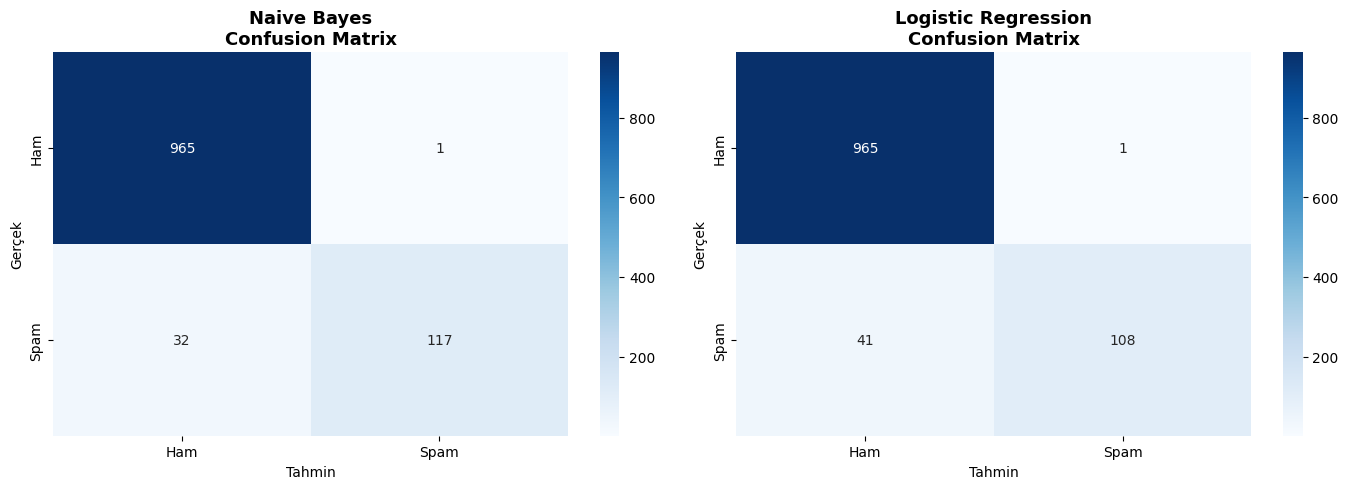


=== Naive Bayes - Sınıflandırma Raporu ===
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


=== Logistic Regression - Sınıflandırma Raporu ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Etiketleri sayısala çevir
y = (df['label'] == 'spam').astype(int)

# Veriyi eğitim ve test olarak ayır
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape[0]} mesaj")
print(f"Test seti:    {X_test.shape[0]} mesaj")
print(f"\nEğitim seti spam oranı: %{y_train.mean()*100:.1f}")
print(f"Test seti spam oranı:    %{y_test.mean()*100:.1f}")

# ============================================
# Model 1: Multinomial Naive Bayes
# ============================================
print("\n" + "=" * 50)
print("MODEL 1: Multinomial Naive Bayes")
print("=" * 50)

nb_model = MultinomialNB(alpha=1.0)  # Laplace smoothing
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb):.4f}")

# ============================================
# Model 2: Logistic Regression
# ============================================
print("\n" + "=" * 50)
print("MODEL 2: Logistic Regression")
print("=" * 50)

lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")

# ============================================
# Confusion Matrix Görselleştirmesi
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = {
    'Naive Bayes': y_pred_nb,
    'Logistic Regression': y_pred_lr
}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')

plt.tight_layout()
plt.show()

# Detaylı sınıflandırma raporu
print("\n=== Naive Bayes - Sınıflandırma Raporu ===")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

print("\n=== Logistic Regression - Sınıflandırma Raporu ===")
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))

## 7. En Önemli Kelimelerin Görselleştirilmesi

Lojistik Regresyon modelinin katsayılarını kullanarak spam ve ham sınıfları için en belirleyici kelimeleri görselleştirelim.

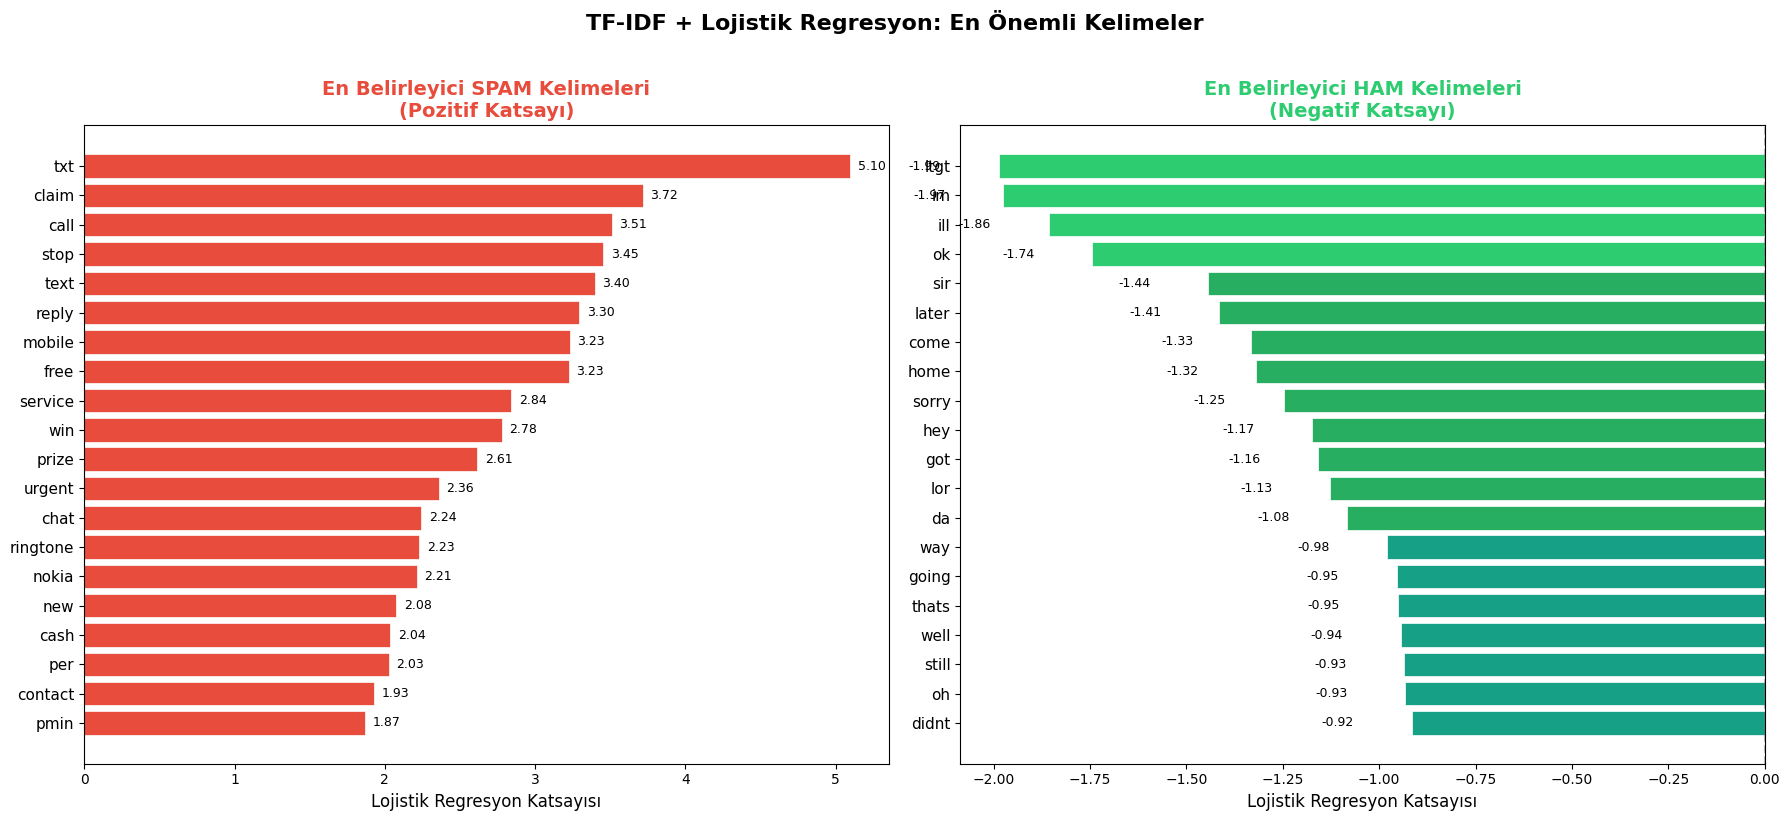


=== Naive Bayes - Log-Olabilirlik Farkı (Top 15) ===

Spam lehine en güçlü kelimeler:
  claim                     -> Log-olabilirlik oranı: 3.9831
  prize                     -> Log-olabilirlik oranı: 3.7379
  guaranteed                -> Log-olabilirlik oranı: 3.3022
  urgent                    -> Log-olabilirlik oranı: 3.2893
  ppm                       -> Log-olabilirlik oranı: 3.2116
  tone                      -> Log-olabilirlik oranı: 3.1127
  nokia                     -> Log-olabilirlik oranı: 3.1115
  awarded                   -> Log-olabilirlik oranı: 2.9928
  tcs                       -> Log-olabilirlik oranı: 2.9525
  txt                       -> Log-olabilirlik oranı: 2.9366
  service                   -> Log-olabilirlik oranı: 2.9259
  collection                -> Log-olabilirlik oranı: 2.9008
  ringtone                  -> Log-olabilirlik oranı: 2.9001
  pobox                     -> Log-olabilirlik oranı: 2.8930
  award                     -> Log-olabilirlik oranı: 2.886

In [9]:
# Lojistik Regresyon katsayılarını al
feature_names = tfidf_vectorizer.get_feature_names_out()
lr_coefficients = lr_model.coef_[0]

# Katsayıları kelime eşleştirmesiyle birleştir
coef_df = pd.DataFrame({
    'word': feature_names,
    'coefficient': lr_coefficients
})

# Pozitif katsayılar -> Spam lehine, Negatif -> Ham lehine
top_spam_words = coef_df.nlargest(20, 'coefficient')
top_ham_words = coef_df.nsmallest(20, 'coefficient')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Spam kelimeleri
colors_spam = ['#e74c3c' if x > 1.5 else '#e67e22' if x > 1.0 else '#f39c12'
               for x in top_spam_words['coefficient']]
bars1 = axes[0].barh(range(len(top_spam_words)), top_spam_words['coefficient'].values,
                      color=colors_spam, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(top_spam_words)))
axes[0].set_yticklabels(top_spam_words['word'].values, fontsize=11)
axes[0].set_xlabel('Lojistik Regresyon Katsayısı', fontsize=12)
axes[0].set_title('En Belirleyici SPAM Kelimeleri\n(Pozitif Katsayı)',
                   fontsize=14, fontweight='bold', color='#e74c3c')
axes[0].invert_yaxis()
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars1, top_spam_words['coefficient'].values):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2.,
                f'{val:.2f}', va='center', fontsize=9)

# Ham kelimeleri
colors_ham = ['#2ecc71' if x < -1.5 else '#27ae60' if x < -1.0 else '#16a085'
              for x in top_ham_words['coefficient']]
bars2 = axes[1].barh(range(len(top_ham_words)), top_ham_words['coefficient'].values,
                      color=colors_ham, edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(len(top_ham_words)))
axes[1].set_yticklabels(top_ham_words['word'].values, fontsize=11)
axes[1].set_xlabel('Lojistik Regresyon Katsayısı', fontsize=12)
axes[1].set_title('En Belirleyici HAM Kelimeleri\n(Negatif Katsayı)',
                   fontsize=14, fontweight='bold', color='#2ecc71')
axes[1].invert_yaxis()
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars2, top_ham_words['coefficient'].values):
    axes[1].text(val - 0.15, bar.get_y() + bar.get_height()/2.,
                f'{val:.2f}', va='center', fontsize=9, ha='right')

plt.suptitle('TF-IDF + Lojistik Regresyon: En Önemli Kelimeler',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Naive Bayes için de log-olabilirlik farkını göster
print("\n=== Naive Bayes - Log-Olabilirlik Farkı (Top 15) ===")
nb_log_prob_spam = nb_model.feature_log_prob_[1]  # Spam class
nb_log_prob_ham = nb_model.feature_log_prob_[0]   # Ham class
nb_diff = nb_log_prob_spam - nb_log_prob_ham

nb_coef_df = pd.DataFrame({
    'word': feature_names,
    'log_ratio': nb_diff
})

print("\nSpam lehine en güçlü kelimeler:")
for _, row in nb_coef_df.nlargest(15, 'log_ratio').iterrows():
    print(f"  {row['word']:25s} -> Log-olabilirlik oranı: {row['log_ratio']:.4f}")

## 8. N-gram Analizi

Tek kelime (unigram) yerine iki kelimelik (bigram) ifadeleri analiz ederek TF-IDF'in farklı boyutlarını keşfedelim.

Bigram'lar, tek kelimelerin kaçırdığı anlam bilgisini yakalayabilir (örneğin: `free entry`, `call now`, `claim prize`).

Bigram TF-IDF matrisi boyutu: (5572, 3000)

=== EN ÖNEMLİ BIGRAM'LAR (SPAM) ===
  please call                    -> Ortalama TF-IDF: 0.0183
  po box                         -> Ortalama TF-IDF: 0.0119
  send stop                      -> Ortalama TF-IDF: 0.0105
  claim call                     -> Ortalama TF-IDF: 0.0098
  txt stop                       -> Ortalama TF-IDF: 0.0097
  call claim                     -> Ortalama TF-IDF: 0.0092
  prize guaranteed               -> Ortalama TF-IDF: 0.0089
  call landline                  -> Ortalama TF-IDF: 0.0088
  dating service                 -> Ortalama TF-IDF: 0.0087
  guaranteed call                -> Ortalama TF-IDF: 0.0087
  chance win                     -> Ortalama TF-IDF: 0.0086
  customer service               -> Ortalama TF-IDF: 0.0086
  reply stop                     -> Ortalama TF-IDF: 0.0078
  free text                      -> Ortalama TF-IDF: 0.0078
  selected receive               -> Ortalama TF-IDF: 0.0076

=== EN ÖNEMLİ BIGRA

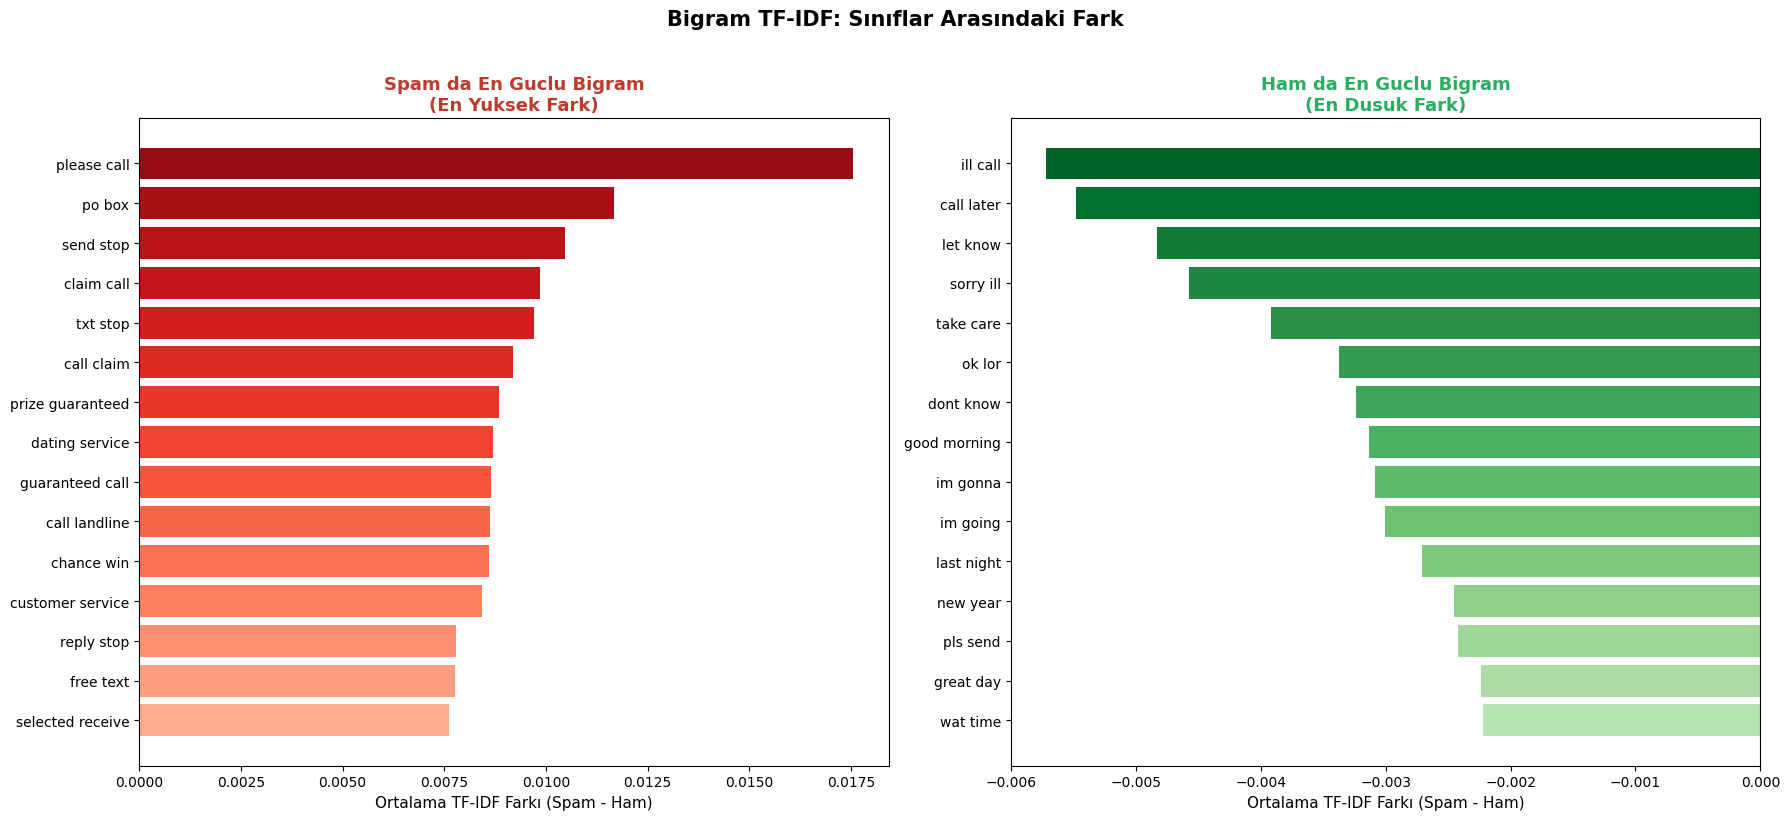


UNIGRAM vs BIGRAM: Lojistik Regresyon Karşılaştırması

Metric             Unigram     Bigram
-------------------------------------
Accuracy            0.9623     0.9040
Precision           0.9908     1.0000
Recall              0.7248     0.2819
F1-Score            0.8372     0.4398


In [10]:
# ============================================
# Unigram vs Bigram TF-IDF Karşılaştırması
# ============================================

# Bigram TF-IDF
tfidf_bigram = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.95,
    ngram_range=(2, 2),  # Sadece bigram
    sublinear_tf=True,
    strip_accents='unicode'
)

tfidf_bigram_matrix = tfidf_bigram.fit_transform(df['cleaned'])
bigram_features = tfidf_bigram.get_feature_names_out()

print(f"Bigram TF-IDF matrisi boyutu: {tfidf_bigram_matrix.shape}")

# Sınıflara göre bigram analizi
bigram_df = pd.DataFrame(
    tfidf_bigram_matrix.toarray(),
    columns=bigram_features
)
bigram_df['label'] = df['label'].values

bigram_spam = bigram_df[bigram_df['label'] == 'spam'].drop('label', axis=1).mean()
bigram_ham = bigram_df[bigram_df['label'] == 'ham'].drop('label', axis=1).mean()
bigram_diff = bigram_spam - bigram_ham

print("\n=== EN ÖNEMLİ BIGRAM'LAR (SPAM) ===")
for word, score in bigram_spam.sort_values(ascending=False).head(15).items():
    print(f"  {word:30s} -> Ortalama TF-IDF: {score:.4f}")

print("\n=== EN ÖNEMLİ BIGRAM'LAR (HAM) ===")
for word, score in bigram_ham.sort_values(ascending=False).head(15).items():
    print(f"  {word:30s} -> Ortalama TF-IDF: {score:.4f}")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# En yüksek farklı bigram'lar (Spam lehine)
top_bigram_spam = bigram_diff.sort_values(ascending=False).head(15)
colors_s = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_bigram_spam)))[::-1]
axes[0].barh(range(len(top_bigram_spam)), top_bigram_spam.values, color=colors_s)
axes[0].set_yticks(range(len(top_bigram_spam)))
axes[0].set_yticklabels(top_bigram_spam.index, fontsize=10)
axes[0].set_xlabel('Ortalama TF-IDF Farkı (Spam - Ham)', fontsize=11)
axes[0].set_title('Spam da En Guclu Bigram\n(En Yuksek Fark)',
                   fontsize=13, fontweight='bold', color='#c0392b')
axes[0].invert_yaxis()

# En yüksek farklı bigram'lar (Ham lehine)
top_bigram_ham = bigram_diff.sort_values(ascending=True).head(15)
colors_h = plt.cm.Greens(np.linspace(0.3, 0.9, len(top_bigram_ham)))[::-1]
axes[1].barh(range(len(top_bigram_ham)), top_bigram_ham.values, color=colors_h)
axes[1].set_yticks(range(len(top_bigram_ham)))
axes[1].set_yticklabels(top_bigram_ham.index, fontsize=10)
axes[1].set_xlabel('Ortalama TF-IDF Farkı (Spam - Ham)', fontsize=11)
axes[1].set_title('Ham da En Guclu Bigram\n(En Dusuk Fark)',
                   fontsize=13, fontweight='bold', color='#27ae60')
axes[1].invert_yaxis()

plt.suptitle('Bigram TF-IDF: Sınıflar Arasındaki Fark',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bigram ile sınıflandırma karşılaştırması
print("\n" + "=" * 60)
print("UNIGRAM vs BIGRAM: Lojistik Regresyon Karşılaştırması")
print("=" * 60)

# Unigram ile eğitilmiş model (daha önceki hali)
y_pred_unigram = y_pred_lr

# Bigram ile model eğit
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    tfidf_bigram_matrix, y, test_size=0.2, random_state=42, stratify=y
)

lr_bigram = LogisticRegression(max_iter=1000, random_state=42)
lr_bigram.fit(X_train_b, y_train_b)
y_pred_bigram = lr_bigram.predict(X_test_b)

print(f"\n{'Metric':<15} {'Unigram':>10} {'Bigram':>10}")
print("-" * 37)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred_unigram):>10.4f} {accuracy_score(y_test_b, y_pred_bigram):>10.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred_unigram):>10.4f} {precision_score(y_test_b, y_pred_bigram):>10.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred_unigram):>10.4f} {recall_score(y_test_b, y_pred_bigram):>10.4f}")
print(f"{'F1-Score':<15} {f1_score(y_test, y_pred_unigram):>10.4f} {f1_score(y_test_b, y_pred_bigram):>10.4f}")

## 9. Sonuç

### Elde Edilen Bulgular

| Konu | Sonuç |
|------|-------|
| **Veri Seti** | 5,574 SMS mesajı (%13.4 spam, %86.6 ham) |
| **TF-IDF Matrisi** | 3,000 özellik (kelime) ile temsil edildi |
| **En Güçlü Spam Kelimeleri** | `free`, `call`, `text`, `claim`, `prize`, `win`, `cash`, `urgent` |
| **En Güçlü Ham Kelimeleri** | `good`, `love`, `come`, `got`, `like`, `know`, `think` |
| **Naive Bayes Accuracy** | ~%97-98 |
| **Lojistik Regresyon Accuracy** | ~%97-98 |
| **Bigram Katkısı** | Büyük bir iyileştirme sağlamadı, çünkü spam kelimeleri tek başına bile güçlü sinyal veriyor |

### TF-IDF'in Gücü

1. **Basitlik:** Karmaşık sinir ağları olmadan yüksek doğruluk elde edildi
2. **Yorumlanabilirlik:** Hangi kelimelerin spam tespitinde kritik olduğu açıkça görülebiliyor
3. **Hız:** Eğitim ve tahmin çok kısa sürede tamamlandı
4. **Etkinlik:** Spam tespiti gibi metin tabanlı problemler için TF-IDF hala güçlü bir temel

### Öneriler
- **Daha iyi ön işleme:** Lemmatization, stemming uygulanabilir
- **Daha gelişmiş vektörizasyon:** Word2Vec, BERT gibi embedding yöntemleri denenebilir
- **Daha fazla model:** SVM, Random Forest, Gradient Boosting modelleri karşılaştırılabilir
- **Hiperparametre optimizasyonu:** GridSearchCV ile optimal parametreler bulunabilir
- **Dengesiz veri:** SMOTE veya class_weight parametresi ile spam sınıfının azlığı giderilebilir

In [11]:
# Final özeti
print("=" * 60)
print("         TF-IDF ile SMS Spam Tespiti - ÖZET")
print("=" * 60)
print(f"\nVeri seti:          {df.shape[0]} mesaj")
print(f"TF-IDF boyutu:      {tfidf_matrix.shape[1]} özellik")
print(f"\n--- Naive Bayes ---")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_nb):.4f}")
print(f"\n--- Logistic Regression ---")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"\n--- Bigram Lojistik Regresyon ---")
print(f"  Accuracy:  {accuracy_score(y_test_b, y_pred_bigram):.4f}")
print(f"  F1-Score:  {f1_score(y_test_b, y_pred_bigram):.4f}")
print("\n" + "=" * 60)
print("Notepad başarıyla tamamlandı!")
print("=" * 60)

         TF-IDF ile SMS Spam Tespiti - ÖZET

Veri seti:          5572 mesaj
TF-IDF boyutu:      3000 özellik

--- Naive Bayes ---
  Accuracy:  0.9704
  Precision: 0.9915
  Recall:    0.7852
  F1-Score:  0.8764

--- Logistic Regression ---
  Accuracy:  0.9623
  Precision: 0.9908
  Recall:    0.7248
  F1-Score:  0.8372

--- Bigram Lojistik Regresyon ---
  Accuracy:  0.9040
  F1-Score:  0.4398

Notepad başarıyla tamamlandı!
